

<br>
<font>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Artificial Intelligence <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Spring 2026<br>
<font color=3C99D size=5>
    Practical Assignment 4

    🌳 Decision Tree 🌳
<font color=green size=5>
Prepared By:
Matin Bagheri


**Student Name:** Arvin Baghal Asl

**Student ID:** 403105793


> **Author's Note**
>
> Hey there, everyone! 👋
> Hope you're doing well.
>
> At first glance, this notebook might look a bit overwhelming, but don't worry—it’s actually much simpler than it seems. Most of the implementation has already been completed for you, so you'll mainly be focusing on the key missing pieces.
>
> Take your time, explore the notebook, and enjoy the process. Let's make some trees! 🌳


---

## Introduction

A **Decision Tree** is one of the most intuitive machine learning models. Like a flowchart, it classifies inputs by asking a sequence of questions, following branches until it reaches a **leaf node** — the final decision.

**Real-world analogy — diagnosing a server problem:**
- *"Is CPU load high?"* → Yes → *"Are there connection errors?"* → Yes → 🚨 **Trigger Alert**

Decision Trees are widely used because they are:
- **Interpretable** — you can read exactly *why* a prediction was made
- **Non-parametric** — no assumptions about the data distribution
- **Versatile** — handle both classification and regression tasks

### In This Notebook You Will:
1. Implement core impurity metrics (**Entropy**, **Gini Impurity**) and **Information Gain** from scratch
2. Build a complete **ID3 Decision Tree** classifier
3. **Visualize** the resulting tree
4. Understand **overfitting** and **Occam's Razor**
5. Implement two post-pruning strategies: **Reduced Error Pruning (REP)** and **Chi-Squared Pruning**

> ✏️ **Instructions:** Find every cell marked `# ── TODO` and complete the implementation according to the docstring, hints, and assertions provided. Do **not** modify the sanity-check cells.


## 🖥️ Problem Space: Server Health Monitoring

You are a software engineer at a cloud hosting company. Your team needs an automated system to decide whether a server should trigger a **maintenance alert** based on its runtime metrics.

Each server is described by the following features:

| Feature | Description | Encoding |
|---|---|---|
| `cpu_load` | CPU utilization level | `low` → 0, `medium` → 1, `high` → 2 |
| `memory_usage` | RAM usage level | `low` → 0, `high` → 1 |
| `connection_errors` | Number of connection errors in the last hour | Integer [0, 20) |
| `response_time` | Average response time (ms) | Integer [50, 500) |
| `uptime_days` | Days since last reboot | Integer [1, 60) |

**Target:** `alert` — `1` if the server needs attention, `0` otherwise.

The dataset is **synthetically generated** with known rules plus a small amount of noise, giving you full control and the ability to trace the logic manually.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
from scipy.stats import chi2 as scipy_chi2
import copy
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
def generate_server_dataset(n: int = 300) -> pd.DataFrame:
    '''Generate a synthetic server health monitoring dataset.'''
    cpu_load      = np.random.choice(['low', 'medium', 'high'], n, p=[0.40, 0.35, 0.25])
    memory_usage  = np.random.choice(['low', 'high'],           n, p=[0.55, 0.45])
    conn_errors   = np.random.randint(0, 20, n)
    response_time = np.random.randint(50, 500, n)
    uptime_days   = np.random.randint(1, 60, n)

    alert = np.zeros(n, dtype=int)
    for i in range(n):
        score = 0
        score += {'low': 0, 'medium': 1, 'high': 3}[cpu_load[i]]
        score += {'low': 0, 'high': 2}[memory_usage[i]]
        score += 2 if conn_errors[i] > 10 else (1 if conn_errors[i] > 5 else 0)
        score += 2 if response_time[i] > 300 else (1 if response_time[i] > 200 else 0)
        score += 1 if uptime_days[i] > 40 else 0
        alert[i] = 1 if score >= 5 else 0

    # ~5% label noise to make the problem realistic
    flip_idx = np.random.choice(n, size=int(0.05 * n), replace=False)
    alert[flip_idx] = 1 - alert[flip_idx]

    return pd.DataFrame({
        'cpu_load':          cpu_load,
        'memory_usage':      memory_usage,
        'connection_errors': conn_errors,
        'response_time':     response_time,
        'uptime_days':       uptime_days,
        'alert':             alert,
    })

df = generate_server_dataset(300)
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (300, 6)


,cpu_load,memory_usage,connection_errors,response_time,uptime_days,alert
0,low,low,4,231,25,0
1,high,low,17,201,18,1
2,medium,low,9,74,25,0
3,medium,high,5,229,12,0
4,low,high,0,247,15,0
5,low,high,4,393,59,1
6,low,low,8,210,26,0
7,high,low,11,226,41,1
8,medium,high,13,334,45,1
9,medium,low,1,112,26,0


Class Distribution:
alert
Alert (1)     155
Normal (0)    145
Alert rate: 51.7%


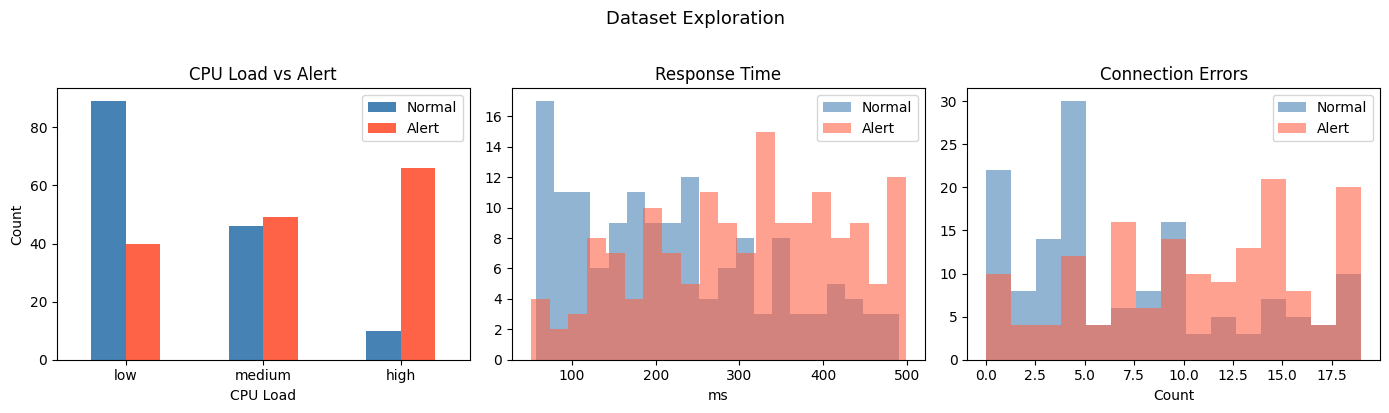

In [3]:
# ── Dataset Exploration ──────────────────────────────────────────────────────
print("Class Distribution:")
print(df['alert'].value_counts().rename({0: 'Normal (0)', 1: 'Alert (1)'}).to_string())
print(f"Alert rate: {df['alert'].mean():.1%}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# CPU Load vs Alert
cpu_counts = df.groupby(['cpu_load', 'alert']).size().unstack(fill_value=0)
cpu_counts.reindex(['low', 'medium', 'high']).plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], rot=0)
axes[0].set_title('CPU Load vs Alert'); axes[0].set_xlabel('CPU Load')
axes[0].set_ylabel('Count'); axes[0].legend(['Normal', 'Alert'])

# Response Time distribution
for val, color, lbl in [(0,'steelblue','Normal'), (1,'tomato','Alert')]:
    axes[1].hist(df[df['alert']==val]['response_time'], bins=20, alpha=0.6,
                 color=color, label=lbl)
axes[1].set_title('Response Time'); axes[1].set_xlabel('ms'); axes[1].legend()

# Connection Errors distribution
for val, color, lbl in [(0,'steelblue','Normal'), (1,'tomato','Alert')]:
    axes[2].hist(df[df['alert']==val]['connection_errors'], bins=15, alpha=0.6,
                 color=color, label=lbl)
axes[2].set_title('Connection Errors'); axes[2].set_xlabel('Count'); axes[2].legend()

plt.suptitle('Dataset Exploration', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 🔧 Data Preprocessing

We encode categorical features as integers and split the data into **three** sets:
- **Training set** (60%) — used to grow the tree
- **Validation set** (20%) — used by Reduced Error Pruning
- **Test set** (20%) — used only for final evaluation (never touch it during training/pruning!)

In [4]:
from sklearn.model_selection import train_test_split

df_enc = df.copy()
df_enc['cpu_load']     = df['cpu_load'].map({'low': 0, 'medium': 1, 'high': 2})
df_enc['memory_usage'] = df['memory_usage'].map({'low': 0, 'high': 1})

X = df_enc.drop('alert', axis=1).values
y = df_enc['alert'].values
feature_names = df_enc.drop('alert', axis=1).columns.tolist()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Training   : {X_train.shape[0]} samples")
print(f"Validation : {X_val.shape[0]} samples")
print(f"Test       : {X_test.shape[0]} samples")
print(f"Features   : {feature_names}")

Training   : 180 samples
Validation : 60 samples
Test       : 60 samples
Features   : ['cpu_load', 'memory_usage', 'connection_errors', 'response_time', 'uptime_days']


---
## 📐 Section 1: Theoretical Foundations

### 1.1 Entropy

**Entropy** measures the *impurity* (or uncertainty) of a set of labels. It originates from information theory (Shannon, 1948).

For a set $S$ with classes $c \in C$:

$$H(S) = -\sum_{c \in C} p_c \log_2(p_c)$$

where $p_c$ is the fraction of samples belonging to class $c$.

**Intuition:**

| Distribution | Entropy |
|---|---|
| [100% class A] | 0.0 — perfectly pure, no uncertainty |
| [75% A, 25% B] | 0.811 — some uncertainty |
| [50% A, 50% B] | 1.0 — maximum uncertainty |
#
> ⚠️ Convention: define $0 \cdot \log_2(0) = 0$ (a class with zero probability contributes nothing).


In [5]:
def entropy(y):
    '''
    Compute the Shannon entropy of a label array.

    Parameters
    ----------
    y : array-like of int
        Class labels, e.g. [0, 1, 1, 0, 1]

    Returns
    -------
    float
        Entropy value in bits. For binary classification: in [0, 1].

    Hints
    -----
    - Use np.unique(y, return_counts=True) to get class counts.
    - Compute probabilities as  p_c = count_c / len(y).
    - Skip any term where p_c == 0  (avoids log(0)).
    '''
    if len(y) == 0:
      return 0.0

    # terms where p == 0 won't be included in method's output by default
    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    return -sum(probabilities * np.log2(probabilities))


# ── Sanity checks (do not modify) ────────────────────────────────────────────
assert entropy([0, 0, 0, 0])         is not None,     "Return a value, not None"
assert abs(entropy([0, 0, 0, 0]) - 0.0)  < 1e-6,     "Pure set → entropy = 0"
assert abs(entropy([0, 1, 0, 1]) - 1.0)  < 1e-6,     "50/50 split → entropy = 1"
assert abs(entropy([0, 0, 1])    - 0.918) < 0.01,    "2/3 vs 1/3 split → ≈0.918"
assert abs(entropy([0, 0, 1, 1, 1]) - 0.971) < 0.01, "Check your formula"
print("✅ All entropy checks passed!")

✅ All entropy checks passed!


**Quick reflection:** Print the entropy of the `alert` column in our dataset.

**Answer the questions below briefly:**

Is it close to 0 (pure) or close to 1 (balanced)? What does that tell you about the dataset?

**Answer:** The entropy is extremely close to 1, which tells us that the dataset is almost perfectly balanced with an equal split of alert and non-alert servers.


In [6]:
# Your exploration here
print(f"Entropy of alert column: {entropy(y_train):.4f}")

Entropy of alert column: 0.9992


### 1.2 Gini Impurity

**Gini Impurity** is an alternative impurity measure used by the **CART** algorithm. It estimates the probability that a randomly chosen sample would be *incorrectly* labelled if assigned a label drawn from the node's class distribution.

$$\text{Gini}(S) = 1 - \sum_{c \in C} p_c^2$$

**Key properties compared to Entropy:**
- Range: **[0, 0.5]** for binary classification (entropy is [0, 1])
- Computationally cheaper (no logarithms needed)
- In practice, results are almost identical to entropy-based splits
- Gini tends to isolate the most frequent class; entropy prefers more balanced splits


In [7]:
def gini_impurity(y):
    '''
    Compute the Gini impurity of a label array.

    Parameters
    ----------
    y : array-like of int
        Class labels.

    Returns
    -------
    float
        Gini impurity in [0, 0.5] for binary classification.

    Hints
    -----
    - Very similar structure to entropy().
    - Instead of  -p * log2(p),  use  p^2.
    - Return  1 - sum(p_c^2).
    '''
    if len(y) == 0:
      return 0.0

    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    return 1 - sum(probabilities ** 2)


# ── Sanity checks ─────────────────────────────────────────────────────────────
assert abs(gini_impurity([0, 0, 0, 0]) - 0.0)   < 1e-6
assert abs(gini_impurity([0, 1, 0, 1]) - 0.5)   < 1e-6
assert abs(gini_impurity([0, 0, 1])    - 0.444) < 0.01
print("✅ All Gini checks passed!")

✅ All Gini checks passed!


### 1.3 Information Gain

**Information Gain (IG)** measures how much a split *reduces* impurity. It is the core criterion used in ID3 to choose which feature to split on at each node.

$$\text{IG}(S, \text{split}) = H(S) - \left( \frac{|S_{\text{left}}|}{|S|} \cdot H(S_{\text{left}}) + \frac{|S_{\text{right}}|}{|S|} \cdot H(S_{\text{right}}) \right)$$

**The higher the information gain, the better the split.**

> 💡 This notebook uses **entropy** as the impurity measure (**ID3** algorithm). Swapping `entropy` for `gini_impurity` gives the **CART** algorithm.


In [8]:
def information_gain(y_parent, y_left, y_right):
    '''
    Compute the Information Gain of a binary split.

    Parameters
    ----------
    y_parent : array-like — labels at the parent node (before the split)
    y_left   : array-like — labels in the left child  (condition is True)
    y_right  : array-like — labels in the right child (condition is False)

    Returns
    -------
    float
        Reduction in entropy after the split. Always >= 0.

    Hints
    -----
    - Compute entropy of the parent.
    - Compute the WEIGHTED average entropy of both children:
          weighted = (len(y_left) / n) * entropy(y_left)
                   + (len(y_right) / n) * entropy(y_right)
    - Return  entropy(parent) - weighted.
    '''
    n = len(y_parent)
    if n == 0:
        return 0.0

    h_parent = entropy(y_parent)
    h_weighted = (len(y_left) / n) * entropy(y_left) + (len(y_right) / n) * entropy(y_right)
    return h_parent - h_weighted


# ── Sanity checks ─────────────────────────────────────────────────────────────
ig_perfect = information_gain([0,0,1,1], [0,0], [1,1])
assert abs(ig_perfect - 1.0) < 1e-6, f"Perfect split → IG=1.0, got {ig_perfect}"

ig_useless = information_gain([0,0,1,1], [0,1], [0,1])
assert abs(ig_useless - 0.0) < 1e-6, f"No-improvement split → IG=0.0, got {ig_useless}"

ig_partial = information_gain([0,0,0,1,1,1], [0,0,0], [1,1,1])
assert abs(ig_partial - 1.0) < 1e-6
print("✅ All Information Gain checks passed!")

✅ All Information Gain checks passed!


In [9]:
# ── Visualise: which feature has the highest IG on our training data? ─────────
print(f"{'Feature':<22} {'Best Threshold':>16} {'Info Gain':>12}")
print("─" * 52)
for fi, fname in enumerate(feature_names):
    col = X_train[:, fi]
    best_ig, best_t = 0.0, None
    for t in np.unique(col):
        mask = col <= t
        if mask.sum() == 0 or (~mask).sum() == 0:
            continue
        ig = information_gain(y_train, y_train[mask], y_train[~mask])
        if ig > best_ig:
            best_ig, best_t = ig, t
    print(f"{fname:<22} {str(best_t):>16} {best_ig:>12.4f}")

Feature                  Best Threshold    Info Gain
────────────────────────────────────────────────────
cpu_load                              1       0.1485
memory_usage                          0       0.0617
connection_errors                     5       0.1123
response_time                       266       0.0713
uptime_days                          35       0.0281


---
## 🏗️ Section 2: Building a Decision Tree from Scratch

Now that we have our building blocks, we can build the full **ID3 Decision Tree** algorithm.

### The Algorithm

```
BuildTree(S, features):
  1. If all samples share the same label → return Leaf(that label)
  2. If stopping condition met (max depth, min samples) → return Leaf(majority class)
  3. For each feature f, compute the best Information Gain split
  4. best_f ← feature/threshold with highest IG
  5. left  ← BuildTree({ x ∈ S | x[best_f] ≤ threshold })
  6. right ← BuildTree({ x ∈ S | x[best_f] >  threshold })
  7. Return Node(split=best_f, left=left, right=right)
```

We use **binary splits**: for each feature we try all unique values as candidate thresholds.


In [10]:
class Node:
    '''A single node in the Decision Tree.'''

    def __init__(self):
        self.feature_index = None  # Which feature to split on
        self.threshold     = None  # Split threshold (left: <=, right: >)
        self.left          = None  # Left child Node
        self.right         = None  # Right child Node
        self.value         = None  # Predicted class (leaf nodes only)
        self.n_samples     = 0     # Number of training samples at this node
        self.impurity      = 0.0   # Entropy at this node

    def is_leaf(self):
        return self.value is not None

    def __repr__(self):
        if self.is_leaf():
            return f"Leaf(class={self.value}, n={self.n_samples})"
        return (f"Node(feature={self.feature_index}, "
                f"threshold={self.threshold:.2f}, n={self.n_samples})")

print("Node class defined ✅")

Node class defined ✅


In [11]:
def find_best_split(X, y):
    '''
    Search over all features and thresholds to find the split with the
    highest Information Gain.

    Parameters
    ----------
    X : np.ndarray, shape (n_samples, n_features)
    y : np.ndarray, shape (n_samples,)

    Returns
    -------
    best_feature   : int   — column index of the best feature to split on
    best_threshold : float — threshold value (split: left <= t, right > t)
    best_ig        : float — information gain of the best split found
    '''
    best_feature   = None
    best_threshold = None
    best_ig        = -1.0

    n_features = X.shape[1]

    for f_i in range(n_features):
        thresholds = np.unique(X[:, f_i])
        for t in thresholds:
            l_mask = X[:, f_i] <= t
            r_mask = ~l_mask
            if l_mask.sum() == 0 or r_mask.sum() == 0:
                continue

            ig = information_gain(y, y[l_mask], y[r_mask])
            if ig > best_ig:
                best_feature = f_i
                best_threshold = t
                best_ig = ig

    return best_feature, best_threshold, best_ig

In [12]:
def build_tree(X, y, depth=0, max_depth=None, min_samples_split=2):
    '''
    Recursively build a Decision Tree using the ID3 algorithm.

    Parameters
    ----------
    X                 : np.ndarray — feature matrix
    y                 : np.ndarray — class labels
    depth             : int        — current recursion depth (do not set manually)
    max_depth         : int|None   — maximum allowed depth (None = no limit)
    min_samples_split : int        — minimum samples required to attempt a split

    Returns
    -------
    Node — root of the (sub)tree
    '''
    node           = Node()
    node.n_samples = len(y)
    node.impurity  = entropy(y)

    # ── Pre-compute majority class (used in all base cases) ──────────────────
    majority_class = int(np.bincount(y).argmax())

    # ── Base cases (stopping conditions) ─────────────────────────────────────
    if (len(np.unique(y)) == 1 or
        len(y) < min_samples_split or
        (max_depth is not None and depth >= max_depth)):
        node.value = majority_class
        return node

    # ── Recursive case ────────────────────────────────────────────────────────
    # Step 1: Call find_best_split(X, y) → best_feature, best_threshold, best_ig

    best_f, best_t, best_ig = find_best_split(X, y)

    # Step 2: If best_ig <= 0 (no useful split exists):

    if best_ig <= 0:
        node.value = majority_class
        return node

    # Step 3: Record the split in the node:

    node.feature_index = best_f
    node.threshold = best_t

    # Step 4: Partition the data:

    l_mask = X[:, best_f] <= best_t
    r_mask = ~l_mask

    # Step 5: Recurse:

    node.left = build_tree(X[l_mask], y[l_mask], depth+1, max_depth, min_samples_split)
    node.right = build_tree(X[r_mask], y[r_mask], depth+1, max_depth, min_samples_split)

    # Step 6: return node
    return node


In [13]:
def predict_sample(node, x):
    '''Traverse the tree to predict the class for a single sample x.'''
    if node.is_leaf():
        return node.value
    if x[node.feature_index] <= node.threshold:
        return predict_sample(node.left, x)
    else:
        return predict_sample(node.right, x)

def predict(tree, X):
    '''Predict class labels for all rows in X.'''
    return np.array([predict_sample(tree, x) for x in X])

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

print("Prediction helpers defined ✅")

Prediction helpers defined ✅


In [14]:
# ── Train the full tree (no depth limit) ─────────────────────────────────────
full_tree = build_tree(X_train, y_train)

train_acc = accuracy(y_train, predict(full_tree, X_train))
test_acc  = accuracy(y_test,  predict(full_tree, X_test))

print(f"Training Accuracy : {train_acc:.1%}")
print(f"Test Accuracy     : {test_acc:.1%}")

Training Accuracy : 100.0%
Test Accuracy     : 70.0%


---
## 📊 Section 3: Visualising the Decision Tree

One of the biggest advantages of Decision Trees is that you can **read the model's logic** directly. Each internal node shows the splitting rule; each leaf shows the predicted class.

> ℹ️ For large trees we limit display to the first few levels. Leaves beyond the cutoff are indicated by faded boxes.

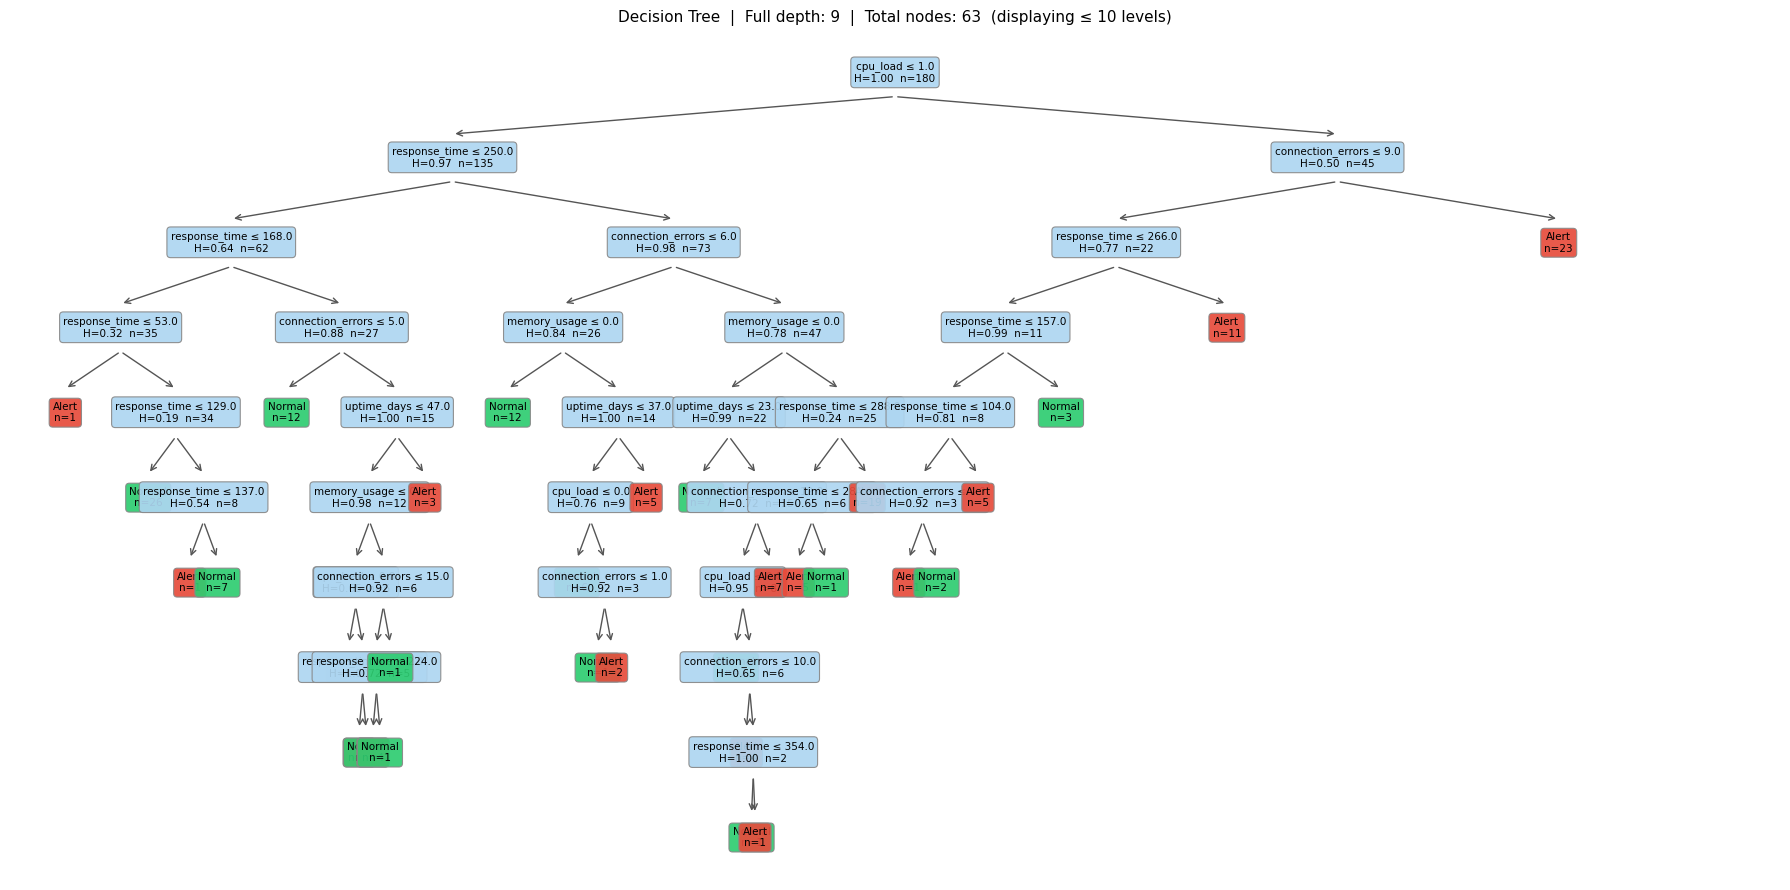

In [15]:
def tree_depth(node):
    if node is None or node.is_leaf(): return 0
    return 1 + max(tree_depth(node.left), tree_depth(node.right))

def count_nodes(node):
    if node is None: return 0
    if node.is_leaf(): return 1
    return 1 + count_nodes(node.left) + count_nodes(node.right)

def plot_tree(root, feature_names, max_display_depth=4, figsize=(18, 9)):
    '''Visualise the decision tree up to max_display_depth levels (BFS layout).'''
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')

    total_depth = min(tree_depth(root), max_display_depth)
    h_step = 1.0 / (total_depth + 1)

    # BFS: each entry = (node, depth, x_min, x_max)
    queue = deque([(root, 0, 0.0, 1.0)])
    node_pos = {}   # id(node) → (cx, cy)

    while queue:
        node, depth, xlo, xhi = queue.popleft()
        if node is None or depth > max_display_depth:
            continue

        cx = (xlo + xhi) / 2.0
        cy = 1.0 - (depth + 0.5) * h_step
        node_pos[id(node)] = (cx, cy)

        if not node.is_leaf() and depth < max_display_depth:
            mid = (xlo + xhi) / 2.0
            queue.append((node.left,  depth + 1, xlo, mid))
            queue.append((node.right, depth + 1, mid, xhi))

    # Draw edges first
    queue2 = deque([(root, 0, 0.0, 1.0)])
    while queue2:
        node, depth, xlo, xhi = queue2.popleft()
        if node is None or node.is_leaf() or depth >= max_display_depth:
            continue
        mid = (xlo + xhi) / 2.0
        px, py = node_pos[id(node)]
        for child, cxlo, cxhi in [(node.left, xlo, mid), (node.right, mid, xhi)]:
            if child is not None and id(child) in node_pos:
                cx, cy = node_pos[id(child)]
                ax.annotate('', xy=(cx, cy + h_step*0.28), xytext=(px, py - h_step*0.28),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=1.0))
        queue2.append((node.left,  depth+1, xlo, mid))
        queue2.append((node.right, depth+1, mid, xhi))

    # Draw nodes
    for node, depth, xlo, xhi in _bfs_list(root, max_display_depth):
        if id(node) not in node_pos: continue
        cx, cy = node_pos[id(node)]
        if node.is_leaf():
            fc = '#2ecc71' if node.value == 0 else '#e74c3c'
            lbl = f"{'Normal' if node.value==0 else 'Alert'}\nn={node.n_samples}"
        else:
            fc = '#aed6f1'
            fname = feature_names[node.feature_index]
            lbl = f"{fname} ≤ {node.threshold:.1f}\nH={node.impurity:.2f}  n={node.n_samples}"
        ax.text(cx, cy, lbl, ha='center', va='center', fontsize=7.5,
                bbox=dict(boxstyle='round,pad=0.35', fc=fc, ec='#888', lw=0.8, alpha=0.92),
                zorder=3)

    d_real = tree_depth(root)
    n_real = count_nodes(root)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.title(f"Decision Tree  |  Full depth: {d_real}  |  Total nodes: {n_real}"
              f"  (displaying ≤ {max_display_depth} levels)", fontsize=11)
    plt.tight_layout(); plt.show()

def _bfs_list(root, max_depth):
    result, queue = [], deque([(root, 0, 0.0, 1.0)])
    while queue:
        node, depth, xlo, xhi = queue.popleft()
        if node is None or depth > max_depth: continue
        result.append((node, depth, xlo, xhi))
        if not node.is_leaf():
            mid = (xlo + xhi) / 2.0
            queue.append((node.left,  depth+1, xlo, mid))
            queue.append((node.right, depth+1, mid, xhi))
    return result

plot_tree(full_tree, feature_names, max_display_depth=10)

---
## ⚠️ Section 4: Overfitting and Occam's Razor

### What is Overfitting?

An unconstrained Decision Tree will keep splitting until every leaf contains samples of a **single class**, achieving 100% training accuracy. However, it will perform poorly on unseen data because it has memorised the training set — including its **noise**.

This is called **overfitting**: the model is too complex and has *over-adapted* to the training data.

### Occam's Razor

> *"Among competing hypotheses that explain the observations equally well, the simplest one should be preferred."*  
> — William of Ockham (1287–1347)

Applied to Decision Trees: **a smaller tree that fits the data reasonably well is preferable to a larger tree that fits it perfectly**. A deeper, more complex tree is harder to interpret and is likely capturing noise rather than genuine patterns.

Practical ways to enforce Occam's Razor in Decision Trees:
| Strategy | Mechanism |
|---|---|
| **`max_depth`** | Limit how deep the tree can grow |
| **`min_samples_split`** | Require a minimum sample count before splitting |
| **Post-pruning** | Grow the full tree, then remove branches that don't generalise |

Let's visualise how training vs. test accuracy vary with tree depth.


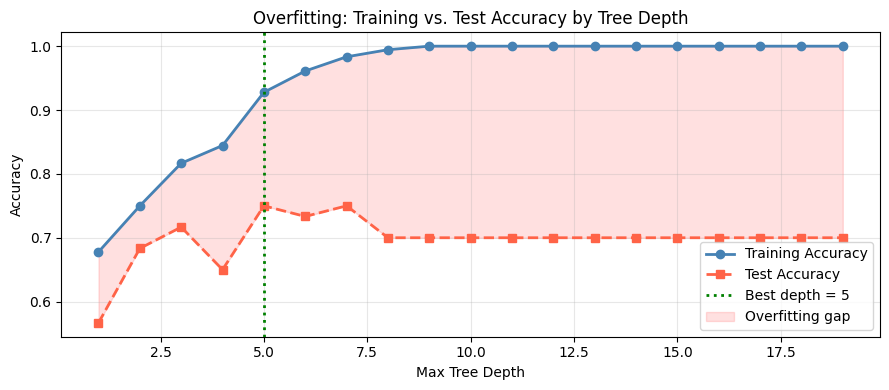

Best max_depth by test accuracy : 5
  Training acc : 92.8%
  Test acc     : 75.0%


In [16]:
depths     = list(range(1, 20))
train_accs = []
test_accs  = []

for d in depths:
    t = build_tree(X_train, y_train, max_depth=d)
    train_accs.append(accuracy(y_train, predict(t, X_train)))
    test_accs.append(accuracy(y_test,  predict(t, X_test)))

best_depth = depths[int(np.argmax(test_accs))]

plt.figure(figsize=(9, 4))
plt.plot(depths, train_accs, 'o-', color='steelblue', label='Training Accuracy', lw=2)
plt.plot(depths, test_accs,  's--', color='tomato',   label='Test Accuracy',     lw=2)
plt.axvline(x=best_depth, color='green', linestyle=':', lw=2,
            label=f'Best depth = {best_depth}')
plt.fill_between(depths, train_accs, test_accs,
                 where=[tr > te for tr, te in zip(train_accs, test_accs)],
                 alpha=0.12, color='red', label='Overfitting gap')
plt.xlabel('Max Tree Depth'); plt.ylabel('Accuracy')
plt.title('Overfitting: Training vs. Test Accuracy by Tree Depth')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"Best max_depth by test accuracy : {best_depth}")
print(f"  Training acc : {train_accs[best_depth-1]:.1%}")
print(f"  Test acc     : {test_accs[best_depth-1]:.1%}")

**Answer the following questions briefly:**
1. At what depth does the training accuracy reach 100%? What is the test accuracy at that point? **At depth 9. At this exact point, the test accuracy is 70.0%.**
2. Does the test accuracy keep improving as depth increases, or does it plateau/degrade? **The test accuracy does not keep improving. It peaks at depth 7, degrades as the tree grows deeper, and completely plateaus at 70.0% from depth 8 onward.**
3. How does this relate to Occam's Razor? **Occam's Razor states that given multiple competing hypotheses, the simplest one is usually the correct one. Here we can see that the simpler tree with depth 5 has the best performance by not overfitting to random data noise.**

---
## ✂️ Section 5: Pruning

**Pruning** removes branches that do not improve generalisation. There are two main families:

| Type | When | How |
|---|---|---|
| **Pre-pruning** | During tree growth | `max_depth`, `min_samples_split`, etc. |
| **Post-pruning** | After full tree is built | Remove/replace subtrees |

We implement two **post-pruning** techniques:
1. **Reduced Error Pruning (REP)** — uses a validation set
2. **Chi-Squared Pruning** — uses a statistical significance test


### 5.1 Reduced Error Pruning (REP)

The algorithm is elegantly simple:

1. Grow the **full** tree on the training set.
2. Traverse nodes **bottom-up** (process children before parents).
3. At each internal node:
   - **Temporarily replace** the subtree with a **leaf** (predict majority class of training samples that reached this node).
   - Evaluate accuracy on the **validation set**.
   - If accuracy **does not decrease** → keep the leaf (pruned version).
   - Otherwise → restore the original subtree.
4. Repeat until no more pruning is beneficial.

**Why it works:** If removing a subtree does not hurt validation accuracy, it was likely memorising training noise — not learning true patterns.

**Important:** REP requires a **separate validation set** that was not used for training. This is why we created a three-way train/val/test split earlier.


In [17]:
def reduced_error_pruning(node: Node, X_val, y_val):
    '''
    Perform Reduced Error Pruning (REP) on the tree rooted at `node`.
    Modifies the tree in-place and returns the (possibly pruned) root.

    Parameters
    ----------
    node  : Node       — root of the subtree to consider pruning
    X_val : np.ndarray — validation features
    y_val : np.ndarray — validation labels

    Returns
    -------
    Node — the (possibly pruned) node

    Algorithm
    ---------
    1. If node is a leaf → nothing to prune, return node.

    2. Route validation samples to the correct child:
        left_mask  = X_val[:, node.feature_index] <= node.threshold
        right_mask = ~left_mask
        Recursively prune both children with their respective subsets.

    3. Consider pruning THIS node:
        a. Record the accuracy of the CURRENT subtree on (X_val, y_val).
        b. Save the current subtree with copy.deepcopy(node).
        c. Convert node to a leaf:
            node.value = majority class in y_val (or keep stored majority if y_val is empty)
            node.left  = None
            node.right = None
        d. Compute accuracy of the new leaf on (X_val, y_val).
        e. If leaf_accuracy >= subtree_accuracy → keep the leaf (pruning helped or tied).
            Else → restore the original subtree from the deepcopy.

    4. Return node.

    Hints
    -----
    - Use predict(node, X_val) to get predictions for the full subtree.
    - After making node a leaf, predict_sample will just return node.value for all samples.
    - Handle the edge case where len(y_val) == 0 (prune by default — no evidence to keep the split).
    - np.bincount(y_val).argmax() gives the majority class.
    '''
    if node.is_leaf():
        return node

    l_mask = X_val[:, node.feature_index] <= node.threshold
    r_mask = ~l_mask

    reduced_error_pruning(node.left, X_val[l_mask], y_val[l_mask])
    reduced_error_pruning(node.right, X_val[r_mask], y_val[r_mask])

    current_acc = accuracy(y_val, predict(node, X_val))
    current_sub = copy.deepcopy(node)

    if len(y_val) == 0:
        if node.left and node.right:
            fallback_val = node.left.value if node.left.n_samples >= node.right.n_samples else node.right.value
        else:
            fallback_val = node.left.value if node.left else (node.right.value if node.right else 0)

        node.value = fallback_val
        node.left  = None
        node.right = None
        return node

    node.value = np.bincount(y_val).argmax()
    node.left = None
    node.right = None

    new_acc = accuracy(y_val, predict(node, X_val))
    if new_acc < current_acc:
        node.feature_index = current_sub.feature_index
        node.threshold = current_sub.threshold
        node.left = current_sub.left
        node.right = current_sub.right
        node.value = current_sub.value
        node.n_samples = current_sub.n_samples
        node.impurity = current_sub.impurity

    return node


# ── Evaluate REP ──────────────────────────────────────────────────────────────
pruned_rep = copy.deepcopy(full_tree)
pruned_rep = reduced_error_pruning(pruned_rep, X_val, y_val)

print("── Before Pruning ───────────────────────────────")
print(f"  Depth      : {tree_depth(full_tree)}")
print(f"  Nodes      : {count_nodes(full_tree)}")
print(f"  Val Acc    : {accuracy(y_val,  predict(full_tree,  X_val)):.1%}")
print(f"  Test Acc   : {accuracy(y_test, predict(full_tree,  X_test)):.1%}")
print()
print("── After Reduced Error Pruning ──────────────────")
print(f"  Depth      : {tree_depth(pruned_rep)}")
print(f"  Nodes      : {count_nodes(pruned_rep)}")
print(f"  Val Acc    : {accuracy(y_val,  predict(pruned_rep, X_val)):.1%}")
print(f"  Test Acc   : {accuracy(y_test, predict(pruned_rep, X_test)):.1%}")

── Before Pruning ───────────────────────────────
  Depth      : 9
  Nodes      : 63
  Val Acc    : 73.3%
  Test Acc   : 70.0%

── After Reduced Error Pruning ──────────────────
  Depth      : 6
  Nodes      : 21
  Val Acc    : 88.3%
  Test Acc   : 76.7%


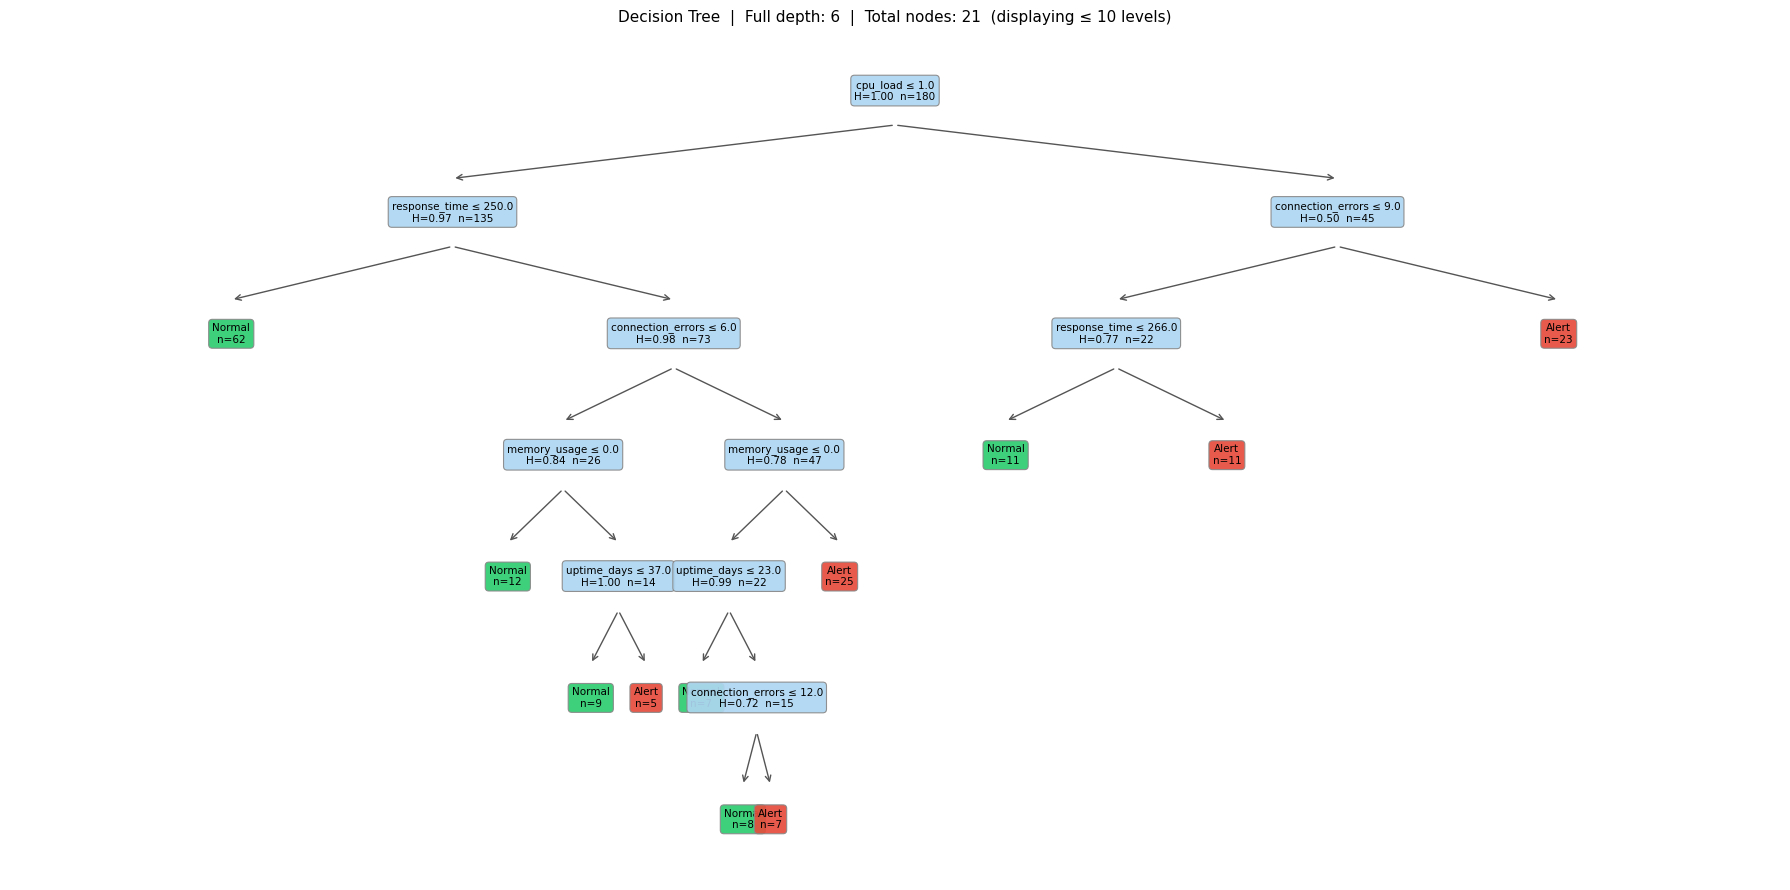

In [18]:
# Visualise the pruned tree
plot_tree(pruned_rep, feature_names, max_display_depth=10)

### 5.2 Chi-Squared Pruning

REP requires a validation set. **Chi-Squared Pruning** instead uses a **statistical hypothesis test** to decide whether a split is meaningful.

**Core idea:** Before keeping a split, test whether the class distribution in the children is *significantly different* from what we would expect by chance.

**Null hypothesis H₀:** The split does not help — the feature is independent of the label at this node.

We compute the **Chi-Squared statistic** summed over both children:

$$\chi^2 = \sum_{\text{child} \in \{L, R\}} \; \sum_{c \in C} \frac{(O_c - E_c)^2}{E_c}$$

where for each child:
- $O_c$ = **observed** count of class $c$ in this child
- $E_c$ = **expected** count of class $c$ if the class distribution matched the parent proportionally:

$$E_c = \frac{|S_c^{\text{parent}}|}{|S^{\text{parent}}|} \cdot |S^{\text{child}}|$$

If $\chi^2$ exceeds the **critical value** at significance level $\alpha$ (e.g. 0.05), we reject H₀ and keep the split. Otherwise we prune it.

> 💡 Degrees of freedom for a binary split with $k$ classes: $\text{df} = (k - 1) \times 1$


In [19]:
def chi_squared_test(y_parent, y_left, y_right, significance=0.05):
    '''
    Perform a Chi-Squared test of independence to decide whether a split
    is statistically significant.

    Parameters
    ----------
    y_parent     : array-like — labels at the parent node
    y_left       : array-like — labels at the left child
    y_right      : array-like — labels at the right child
    significance : float      — significance level alpha (default 0.05)

    Returns
    -------
    bool
        True  → split IS significant     (keep the split)
        False → split is NOT significant (prune the split)

    Steps
    -----
    1. Find all unique classes C from y_parent.
    2. Compute total counts: n_parent = len(y_parent).
    3. For each child y_child in [y_left, y_right]:
         n_child = len(y_child)
         For each class c in C:
           O_c = number of samples of class c in y_child
           E_c = (count of c in y_parent / n_parent) * n_child
           If E_c > 0:  chi2_stat += (O_c - E_c)**2 / E_c
    4. Degrees of freedom: df = (len(C) - 1) * 1
    5. critical_value = scipy_chi2.ppf(1 - significance, df)
       (Hint: scipy_chi2.ppf(0.95, df=1) ≈ 3.841)
    6. Return  chi2_stat > critical_value

    Edge cases
    ----------
    - If len(y_left) == 0 or len(y_right) == 0: return False (trivial split).
    - If df == 0 (only one class): return False.
    '''
    y_parent = np.array(y_parent)
    y_left   = np.array(y_left)
    y_right  = np.array(y_right)

    if len(y_left) == 0 or len(y_right) == 0:
        return False

    classes  = np.unique(y_parent)
    n_parent = len(y_parent)

    df = (len(classes) - 1) * 1
    if df == 0:
        return False

    chi2_stat = 0.0

    for y_child in [y_left, y_right]:
        n_child = len(y_child)
        for c in classes:
            O_c = np.sum(y_child == c)
            E_c = (np.sum(y_parent == c) / n_parent) * n_child

            if E_c > 0:
                chi2_stat += (O_c - E_c) ** 2 / E_c

    c_value = scipy_chi2.ppf(1 - significance, df)

    return chi2_stat > c_value

# ── Sanity checks ─────────────────────────────────────────────────────────────
# Perfect split: all 0s left, all 1s right → highly significant
assert chi_squared_test([0,0,0,1,1,1], [0,0,0], [1,1,1]) == True,  \
    "A perfect split should be statistically significant"
# Identical distributions: no signal whatsoever → not significant
assert chi_squared_test([0,1,0,1,0,1], [0,1,0], [1,0,1]) == False, \
    "Identical distributions should NOT be significant"
print("✅ Chi-Squared checks passed!")

✅ Chi-Squared checks passed!


In [20]:
def chi_squared_pruning(node, X_train, y_train, significance=0.05):
    '''
    Top-down post-pruning using Chi-Squared significance testing.

    At each node, check if the split is statistically significant.
    If not → replace the node with a leaf (majority class of training samples).
    If yes → recurse into children.

    Parameters
    ----------
    node        : Node
    X_train     : np.ndarray — training samples that reached this node
    y_train     : np.ndarray — corresponding training labels
    significance: float      — significance level (default 0.05)

    Returns
    -------
    Node (possibly replaced by a leaf)
    '''
    if node.is_leaf() or len(y_train) == 0:
        return node

    mask    = X_train[:, node.feature_index] <= node.threshold
    y_left  = y_train[mask]
    y_right = y_train[~mask]
    X_left  = X_train[mask]
    X_right = X_train[~mask]

    if not chi_squared_test(y_train, y_left, y_right, significance):
        leaf           = Node()
        leaf.value     = int(np.bincount(y_train).argmax())
        leaf.n_samples = len(y_train)
        leaf.impurity  = entropy(y_train)
        return leaf

    node.left  = chi_squared_pruning(node.left,  X_left,  y_left,  significance)
    node.right = chi_squared_pruning(node.right, X_right, y_right, significance)
    return node


# ── Evaluate Chi-Squared Pruning ──────────────────────────────────────────────
pruned_chi = copy.deepcopy(full_tree)
pruned_chi = chi_squared_pruning(pruned_chi, X_train, y_train, significance=0.05)

print("── After Chi-Squared Pruning ────────────────────")
print(f"  Depth      : {tree_depth(pruned_chi)}")
print(f"  Nodes      : {count_nodes(pruned_chi)}")
print(f"  Test Acc   : {accuracy(y_test, predict(pruned_chi, X_test)):.1%}")

── After Chi-Squared Pruning ────────────────────
  Depth      : 6
  Nodes      : 31
  Test Acc   : 70.0%


In [21]:
# ── Try different significance levels ────────────────────────────────────────
alphas = [0.001, 0.01, 0.05, 0.10, 0.25, 0.50]
print(f"{'Alpha':>8} {'Depth':>7} {'Nodes':>7} {'Test Acc':>10}")
print("─" * 38)
for a in alphas:
    pt = copy.deepcopy(full_tree)
    pt = chi_squared_pruning(pt, X_train, y_train, significance=a)
    print(f"{a:>8.3f} {tree_depth(pt):>7} {count_nodes(pt):>7} {accuracy(y_test, predict(pt, X_test)):>10.1%}")

   Alpha   Depth   Nodes   Test Acc
──────────────────────────────────────
   0.001       5      11      71.7%
   0.010       5      15      75.0%
   0.050       6      31      70.0%
   0.100       7      51      75.0%
   0.250       9      63      70.0%
   0.500       9      63      70.0%


---
## 📊 Section 6: Summary and Comparison

Let's compare all tree variants side by side.


In [22]:
limited_tree = build_tree(X_train, y_train, max_depth=best_depth)

results = {
    'Full Tree (no limit)':       full_tree,
    f'Max Depth = {best_depth}':  limited_tree,
    'Reduced Error Pruning':      pruned_rep,
    'Chi-Squared Pruning (0.05)': pruned_chi,
}

print(f"{'Model':<28} {'Depth':>6} {'Nodes':>7} {'Train':>8} {'Val':>8} {'Test':>8}")
print("─" * 70)
for name, t in results.items():
    tr = accuracy(y_train, predict(t, X_train))
    va = accuracy(y_val,   predict(t, X_val))
    te = accuracy(y_test,  predict(t, X_test))
    print(f"{name:<28} {tree_depth(t):>6} {count_nodes(t):>7} {tr:>8.1%} {va:>8.1%} {te:>8.1%}")

Model                         Depth   Nodes    Train      Val     Test
──────────────────────────────────────────────────────────────────────
Full Tree (no limit)              9      63   100.0%    73.3%    70.0%
Max Depth = 5                     5      35    92.8%    83.3%    75.0%
Reduced Error Pruning             6      21    86.7%    88.3%    76.7%
Chi-Squared Pruning (0.05)        6      31    92.2%    73.3%    70.0%


---
## 🎓 Conclusion

Congratulations on completing this assignment! Here is a summary of what you implemented:

| ✅ | Concept |
|---|---|
| 🔢 | **Entropy** — measures node impurity using information theory |
| 📉 | **Gini Impurity** — alternative impurity measure used by CART |
| 📈 | **Information Gain** — selects the best feature/threshold for each split |
| 🌳 | **ID3 Decision Tree** — recursive tree-building algorithm |
| 🎨 | **Tree Visualisation** — reading the model's logic directly |
| ⚠️ | **Overfitting** — deep trees memorise noise, not patterns |
| 🧠 | **Occam's Razor** — prefer the simplest model that fits the data |
| ✂️ | **Reduced Error Pruning** — post-prune using a held-out validation set |
| 📊 | **Chi-Squared Pruning** — post-prune using statistical hypothesis testing |

---
